# Problem set 2: example workflow

Import necessary modules:

In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

## Exercise 6.5

Load `SWE_tele.csv`, split the training and testing data, and scale both the X and y variables:

In [2]:
swe = pd.read_csv('SWE_tele.csv')

# only SWE (y), Nino34 (x1), PNA (x2) are used
X = swe.iloc[:, 2:4]
y = swe.iloc[:, 1]
y = y.to_numpy().reshape(-1, 1)   # To make it an array with a shape of (-1, 1) for the scaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=40, shuffle=False)

# Scale the data
scaler_x = StandardScaler()
scaler_x.fit(X_train)
X_train_scaled = scaler_x.transform(X_train)
X_test_scaled  = scaler_x.transform(X_test)
scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

We start from an MLR model ($y = a_1x_1 + a_2x_2 + \epsilon$). Note that we do not need the intercept term here because it will be zero when using the standardized X and y. You can also review the example workflow of Problem Set 2 for explanations of the code.

In [3]:
a, res, _, _ = lstsq(X_train_scaled, y_train_scaled.ravel())
r2_train = 1 - res / (y_train_scaled.size * y_train_scaled.var())
pred_test = X_test_scaled @ a
r2_test  = 1 - mean_squared_error(y_test_scaled, pred_test, squared=True) / y_test_scaled.var()    # This is equivalent to the equation 1 - SSR_res / SSR_tot

# This is to calculate the RMSE at the original scale
pred_test_scaledback = scaler_y.inverse_transform(pred_test.reshape(-1, 1))

rmse_test  = mean_squared_error(y_test, pred_test_scaledback , squared=False)
rxy, _ = pearsonr(y_test.ravel(), pred_test_scaledback.ravel())

print(f'Optimized OLS model: y = {a[0]:.2f}x1 + {a[1]:.2f}x2')
print(f'Training set R^2 = {r2_train:.2f}')
print(f'Testing set R^2 = {r2_test:.2f}')
print(f'RMSE of the testing set = {rmse_test:.2f}')
print(f'Pearson r between the observation and prediction for the testing set = {rxy:.2f}')

Optimized OLS model: y = -0.12x1 + -0.45x2
Training set R^2 = 0.26
Testing set R^2 = 0.11
RMSE of the testing set = 519.30
Pearson r between the observation and prediction for the testing set = 0.37


Now let's try to build a non-linear model. For this question, we use the MLP NN with an ensemble size of 10. We also aribtrarily select the other hyperparameters as follows:

In [4]:
mlpnn_fixed_settings = {'hidden_layer_sizes': 10,    # Number of hidden nodes
                        'activation': 'logistic',    # Using logistic function as the activation function
                        'solver': 'lbfgs',           # Optimizer in the family of quasi-Newton methods (Section 7.8)
                        'max_iter': 1000}            # Maximum iterations (i.e., maximum possible epochs)
# For this exercise, no early stoppping method is used. Learning rate is fixed at 0.001 (defaults).

We do want to fine-tune one of the hyperparameters as a demo: the L-2 regularization term ($\alpha$). We perform this using the leave-one-out cross validation:

In [5]:
alpha_list = [0.03, 0.1, 0.3, 1, 3, 10]   # all possible values of alpha

for alpha in alpha_list:
    mlpnn = MLPRegressor(alpha=alpha, **mlpnn_fixed_settings)

    # Perform cross validation. cv is set equal to the number of observations (now 40-fold), meaning that there is only one data point for validation each time.
    # The scoring now is the squared bias (times -1) of that validation point.
    cv_allscores = cross_val_score(mlpnn, X_train_scaled, y_train_scaled.ravel(), scoring='neg_mean_squared_error', cv=40)
    
    cv_avgscore = cv_allscores.mean()
    print(f'alpha = {alpha}, \tcross-validation score = {cv_avgscore:.3f}')

alpha = 0.03, 	cross-validation score = -1.276
alpha = 0.1, 	cross-validation score = -0.907
alpha = 0.3, 	cross-validation score = -0.833
alpha = 1, 	cross-validation score = -0.894
alpha = 3, 	cross-validation score = -0.928
alpha = 10, 	cross-validation score = -1.052


Now it looks like $\alpha=0.3$ is the best number for this hypterparameter. We stick to this number and construct an ensemble model using MLP NN:

In [2]:
class MLPNN_ensemble:

    def __init__(self, ensemble_size=10):
        self.ensemble_size = ensemble_size
        self.individual_estimators = []

    def set_individual_estimators(self, X, y, **kwargs):
        """
        Fit each individual member.
        """
        for i in range(self.ensemble_size):
            mlpnn = MLPRegressor(random_state=i, **kwargs)
            regr = mlpnn.fit(X, y)
            self.individual_estimators.append(regr)

    def predict(self, X_pred):
        """
        Similar to scikit-learn regressor's `predict` method. Returns the mean value of the individual predictions. 
        """
        y_pred_list = []
        for regr in self.individual_estimators:
            y_pred_individual = regr.predict(X_pred)
            y_pred_list.append(y_pred_individual)
        y_pred_collection = np.vstack(y_pred_list)
        y_pred = np.mean(y_pred_collection, axis=0)
        return y_pred

Now we can use `MLPNN_ensemble` to construct our model with `ensemble_size=10` and `alpha=0.3`:

In [7]:
mlpnn_ens = MLPNN_ensemble( )
mlpnn_ens.set_individual_estimators(X_train_scaled, y_train_scaled.ravel(), alpha=0.3, **mlpnn_fixed_settings)
y_train_scaled_pred = mlpnn_ens.predict(X_train_scaled)
y_test_scaled_pred  = mlpnn_ens.predict(X_test_scaled)

# Calculate R^2
r2_train = 1 - mean_squared_error(y_train_scaled, y_train_scaled_pred, squared=True) / y_train_scaled.var()
r2_test  = 1 - mean_squared_error(y_test_scaled,  y_test_scaled_pred,  squared=True) / y_test_scaled.var()

# Calculate RMSE and Pearson's r for the testing data
pred_test_scaledback = scaler_y.inverse_transform(y_test_scaled_pred.reshape(-1, 1))
rmse_test  = mean_squared_error(y_test, pred_test_scaledback , squared=False)
rxy, _ = pearsonr(y_test.ravel(), pred_test_scaledback.ravel())

print(f'Training set R^2 = {r2_train:.2f}')
print(f'Testing set R^2 = {r2_test:.2f}')
print(f'RMSE of the testing set = {rmse_test:.2f}')
print(f'Pearson r between the observation and prediction for the testing set = {rxy:.2f}')

Training set R^2 = 0.40
Testing set R^2 = 0.22
RMSE of the testing set = 484.92
Pearson r between the observation and prediction for the testing set = 0.51


So you can see:
- MLR: RMSE of the testing set = 519.30; Pearson's r = 0.37
- MLP NN: RMSE of the testing set = 484.92; Pearson's r = 0.51

That is, a non-linear model better fits the pattern in the data than a linear model.

### Visualization

Here's a sample visualization for the MLR and MLP NN results. You can check how the non-linear model actually looks like: (Setting `%matplotlib widget` will allow you to view the plots from different angles using mouse drag.)

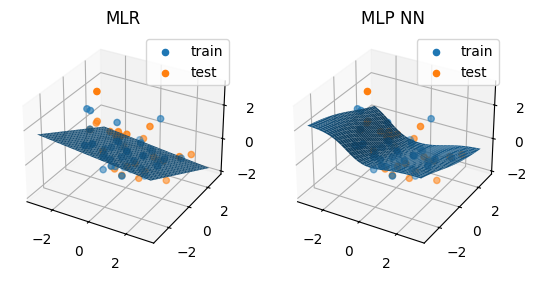

In [8]:
x1v, x2v = np.meshgrid(np.linspace(-3, 3, 61), np.linspace(-3, 3, 61))
X_mesh = np.hstack((x1v.reshape(-1, 1), x2v.reshape(-1, 1)))

y_pred_mesh1 = X_mesh @ a
yv1 = y_pred_mesh1.reshape(61, 61)

y_pred_mesh2  = mlpnn_ens.predict(X_mesh)
yv2 = y_pred_mesh2.reshape(61, 61)

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

ax1.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], y_train_scaled, label='train')
ax1.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], y_test_scaled, label='test')
ax1.plot_surface(x1v, x2v, yv1)
ax1.legend()
ax1.set_title('MLR')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], y_train_scaled, label='train')
ax2.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], y_test_scaled, label='test')
ax2.plot_surface(x1v, x2v, yv2)
ax2.legend()
ax2.set_title('MLP NN');

## Exercise 8.1 and visualizations

Load the first data set:

In [3]:
data_train = np.loadtxt('data_noise-1sigma_train.csv', delimiter=',')
X_train = data_train[:, 0].reshape(-1, 1)    # Need to reshape so the length in x is 1
y_train = data_train[:, 1]
data_test = np.loadtxt('data_noise-1sigma_test.csv', delimiter=',')
X_test = data_test[:, 0].reshape(-1, 1)    # Need to reshape so the length in x is 1
y_test = data_test[:, 1]

We can continue to use the `MLPNN_ensemble` class we created in the previous problem. Specify the fixed settings of the MLP NN:

In [4]:
mlpnn_fixed_settings = {'activation': 'logistic',
                        'solver': 'adam',    # This time we use a stochastic gradient-based optimizer (so that early stopping can work)
                        'max_iter': 1000,
                        'early_stopping': True,         # This time we use the early stopping technique as the regularization
                        'validation_fraction': 0.15,    # Saving 15% data for assessing the early stopping criteria
                        'n_iter_no_change': 50,         # early stopping criteria
                        'alpha': 0.0}     # No L-2 regularization this time

This time we tune the most important hyperparameter: learning rate ($\eta$), which can be done by comparing the RMSE of the training set:

In [5]:
learning_rate_list = np.logspace(-2, 0.5, 20)

for learning_rate in learning_rate_list:
    mlpnn_ens = MLPNN_ensemble(ensemble_size=10)
    mlpnn_ens.set_individual_estimators(X_train, y_train, hidden_layer_sizes=8, learning_rate_init=learning_rate, **mlpnn_fixed_settings)
    y_train_pred = mlpnn_ens.predict(X_train)
    rmse_train  = mean_squared_error(y_train, y_train_pred, squared=False)
    print(f'Learning rate = {learning_rate:.4f}, training RMSE = {rmse_train:.4f}')


Learning rate = 0.0100, training RMSE = 0.9704
Learning rate = 0.0135, training RMSE = 0.9703
Learning rate = 0.0183, training RMSE = 0.9706
Learning rate = 0.0248, training RMSE = 0.9696
Learning rate = 0.0336, training RMSE = 0.9696
Learning rate = 0.0455, training RMSE = 0.9690
Learning rate = 0.0616, training RMSE = 0.9689
Learning rate = 0.0834, training RMSE = 0.9688
Learning rate = 0.1129, training RMSE = 0.9703
Learning rate = 0.1528, training RMSE = 0.9709
Learning rate = 0.2069, training RMSE = 0.9303
Learning rate = 0.2801, training RMSE = 0.8357
Learning rate = 0.3793, training RMSE = 0.8407
Learning rate = 0.5135, training RMSE = 0.8019
Learning rate = 0.6952, training RMSE = 0.8574
Learning rate = 0.9412, training RMSE = 0.9536
Learning rate = 1.2743, training RMSE = 0.9903
Learning rate = 1.7252, training RMSE = 0.9994
Learning rate = 2.3357, training RMSE = 0.9997
Learning rate = 3.1623, training RMSE = 0.9989


As observed here and stated in Section 8.6, the training error tends to decrease gradually as the learning rate increases; however, it increases very steeply when the learning rate becomes too large. We choose $\eta = 0.5$ based on the results above and perform the ensemble MLP NN for each hidden layer number and ensemble size, with visualization.

In [6]:
def exec8_1_main_workflow(X_train, y_train, X_test, y_test, mlpnn_fixed_settings):

    hidden_layer_sizes_list = [2, 3, 4, 5, 6, 7, 8]
    ensemble_size_list = [25, 50, 100]

    # 7 x 3 subplots, each representing a combination of hidden layer and ensemble size
    fig, axs = plt.subplots(7, 3, figsize=(18, 25), sharex=True, sharey=True)
    
    for m in range(7):
        hidden_layer_sizes = hidden_layer_sizes_list[m]
        for n in range(3):
            ensemble_size = ensemble_size_list[n]

            # Plot data and true signal (blue tone)
            gca = axs[m, n]
            gca.plot(X_test, y_test, '.', color='xkcd:cerulean', markersize=2)
            gca.plot(X_test, np.sin(2 * np.pi * X_test), color='xkcd:slate blue', linewidth=2)

            # Initiate the MLPNN_ensemble instance
            mlpnn_ens = MLPNN_ensemble(ensemble_size=ensemble_size)
            mlpnn_ens.set_individual_estimators(X_train, y_train, hidden_layer_sizes=hidden_layer_sizes, learning_rate_init=0.5, **mlpnn_fixed_settings)

            # Loop through individual ensemble members and visualize their predictions    
            rmse_indi_list = []
            for i in mlpnn_ens.individual_estimators:
                y_pred_indi = i.predict(X_test)
                gca.plot(X_test, y_pred_indi, '--', color='xkcd:orange', linewidth=1)
                rmse_indi  = mean_squared_error(y_test, y_pred_indi, squared=False)
                rmse_indi_list.append(rmse_indi)

            # Average RMSE of the individual ensemble models
            rmse_indi_avg = np.mean(rmse_indi_list)

            # Plot the ensemble predictions and calculate the associated RMSE    
            y_pred_ens = mlpnn_ens.predict(X_test)
            gca.plot(X_test, y_pred_ens,color='xkcd:hot pink', linewidth=2)
            rmse_ens = mean_squared_error(y_test, y_pred_ens, squared=False)

            # Add the labels and the RMSE values onto the plot
            gca.text(0.05, 0.05, f"Hidden nodes = {hidden_layer_sizes} \nEnsemble size = {ensemble_size:3n} \nAvg RMSE of indv. models = {rmse_indi_avg:.3f} \nRMSE of Ens. = {rmse_ens:.3f}",
                     transform=gca.transAxes)

### Visualization

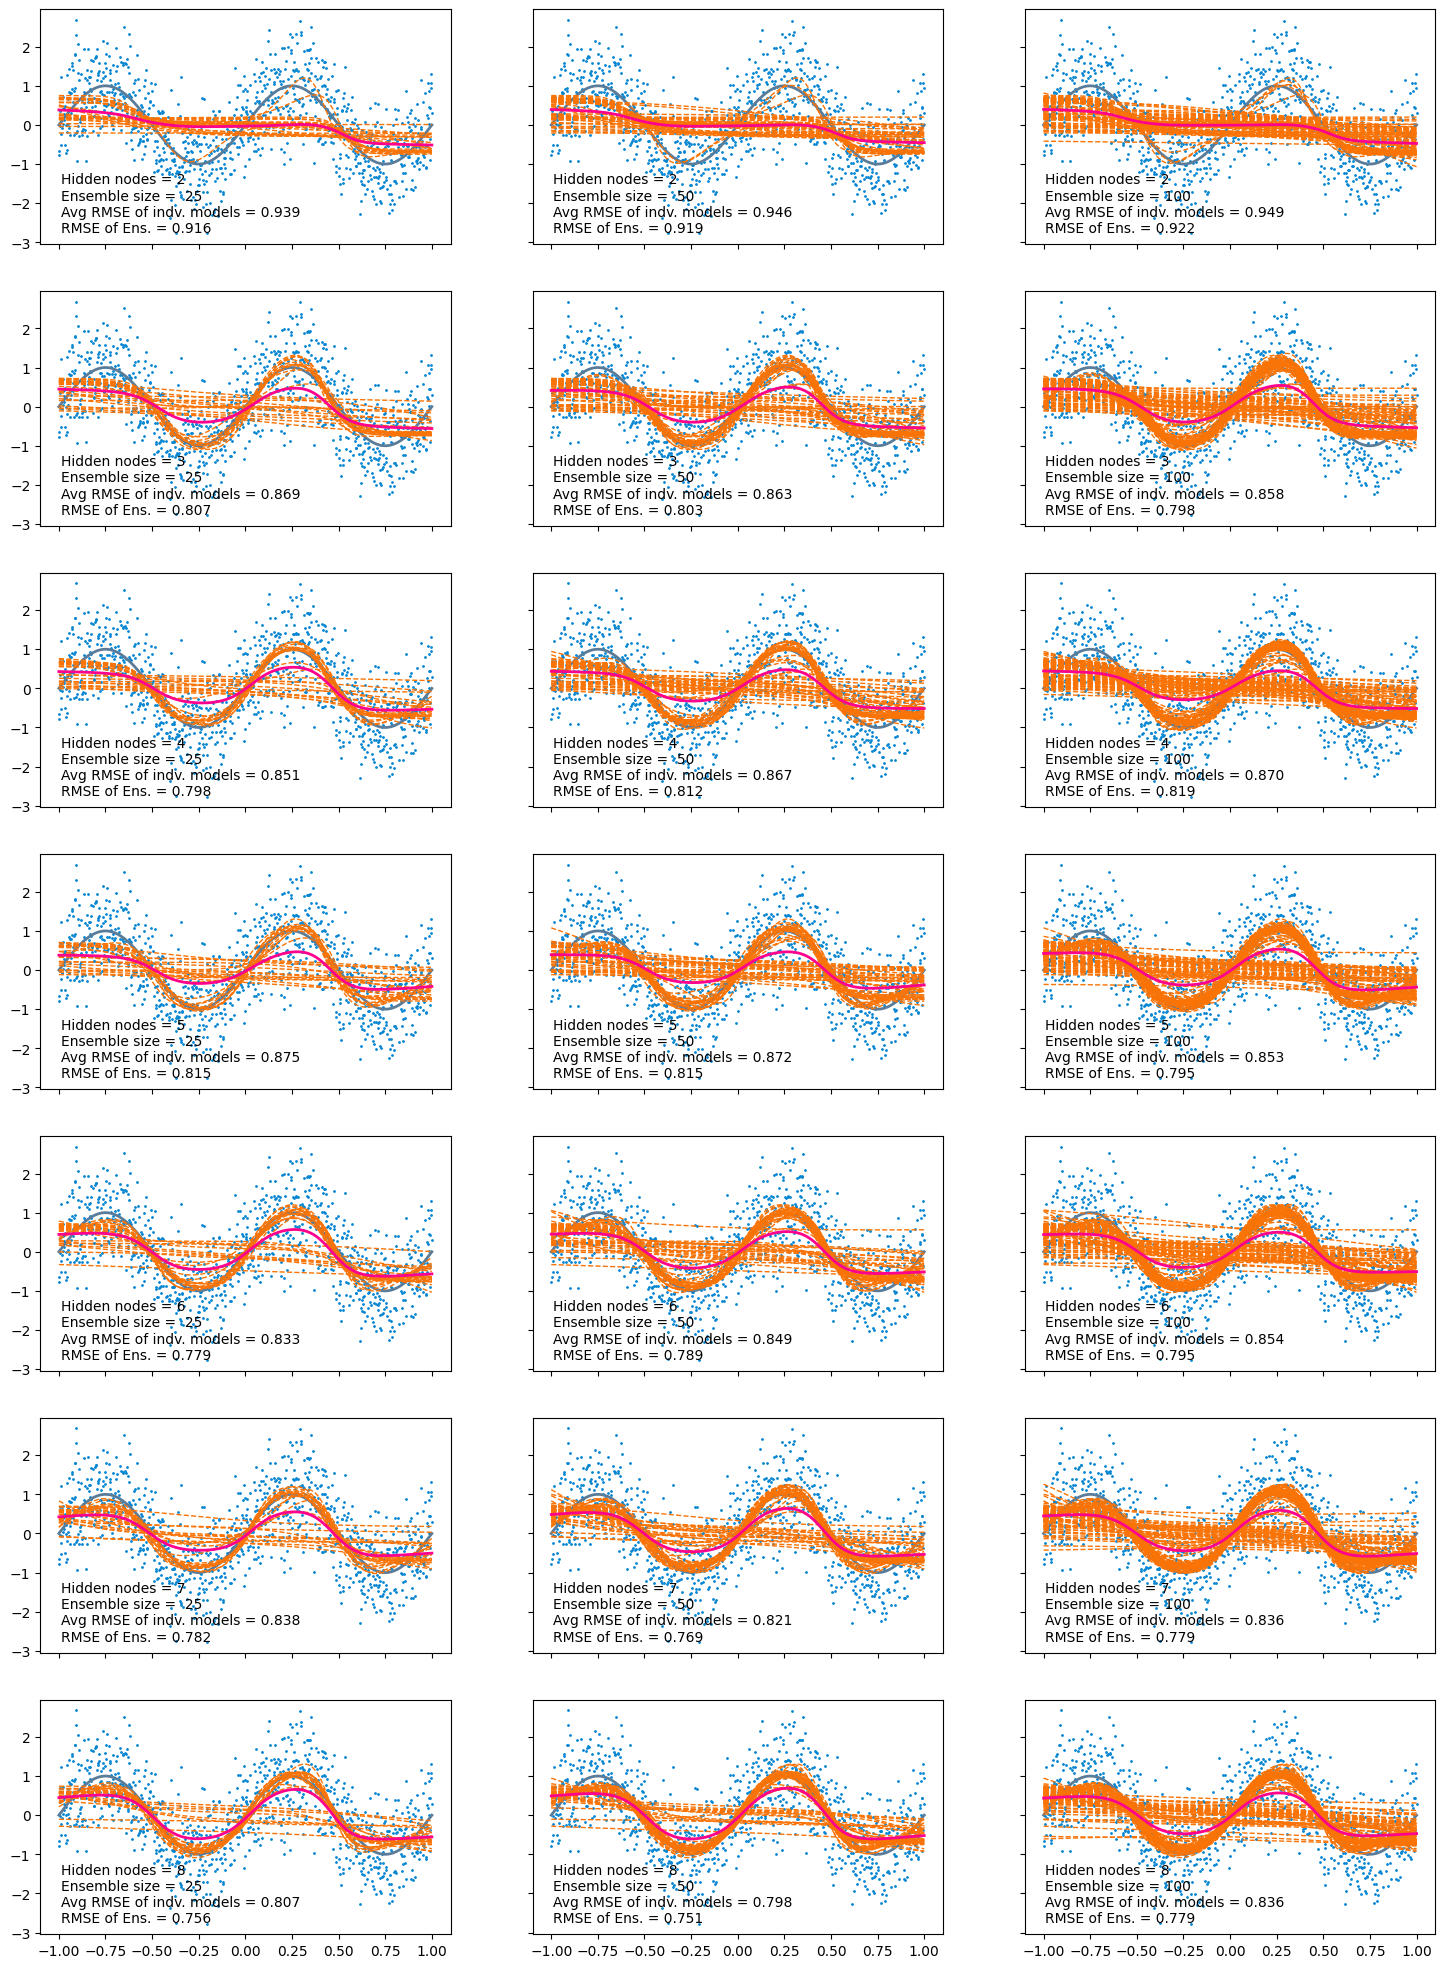

In [7]:
exec8_1_main_workflow(X_train, y_train, X_test, y_test, mlpnn_fixed_settings)

Legend of the plot:
- Blue dots: test data
- Blue thick line: true signal
- Orange dashed lines: individual member predictions
- Pink thick line: ensemble prediction

You can see that not every ensemble member fits the data well. Some of them did not learn anything from the data, and the relevant predictions are nearly horizontal. This situation worsens when the number of hidden nodes decreases, implying a reduced capacity for non-linear regression.

Here is a summary we can make from the results:
- Ensemble RMSE is systematically smaller than the average RMSE of the individual members.
- Ensemble size does not matter significantly here, as 25 and 100 members yield similar results and RMSE.
- Increasing the hidden node size improves the fitting of the non-linear trend.

We can repeat with different magnitudes of Gaussian noise:

#### sigma = 0.5

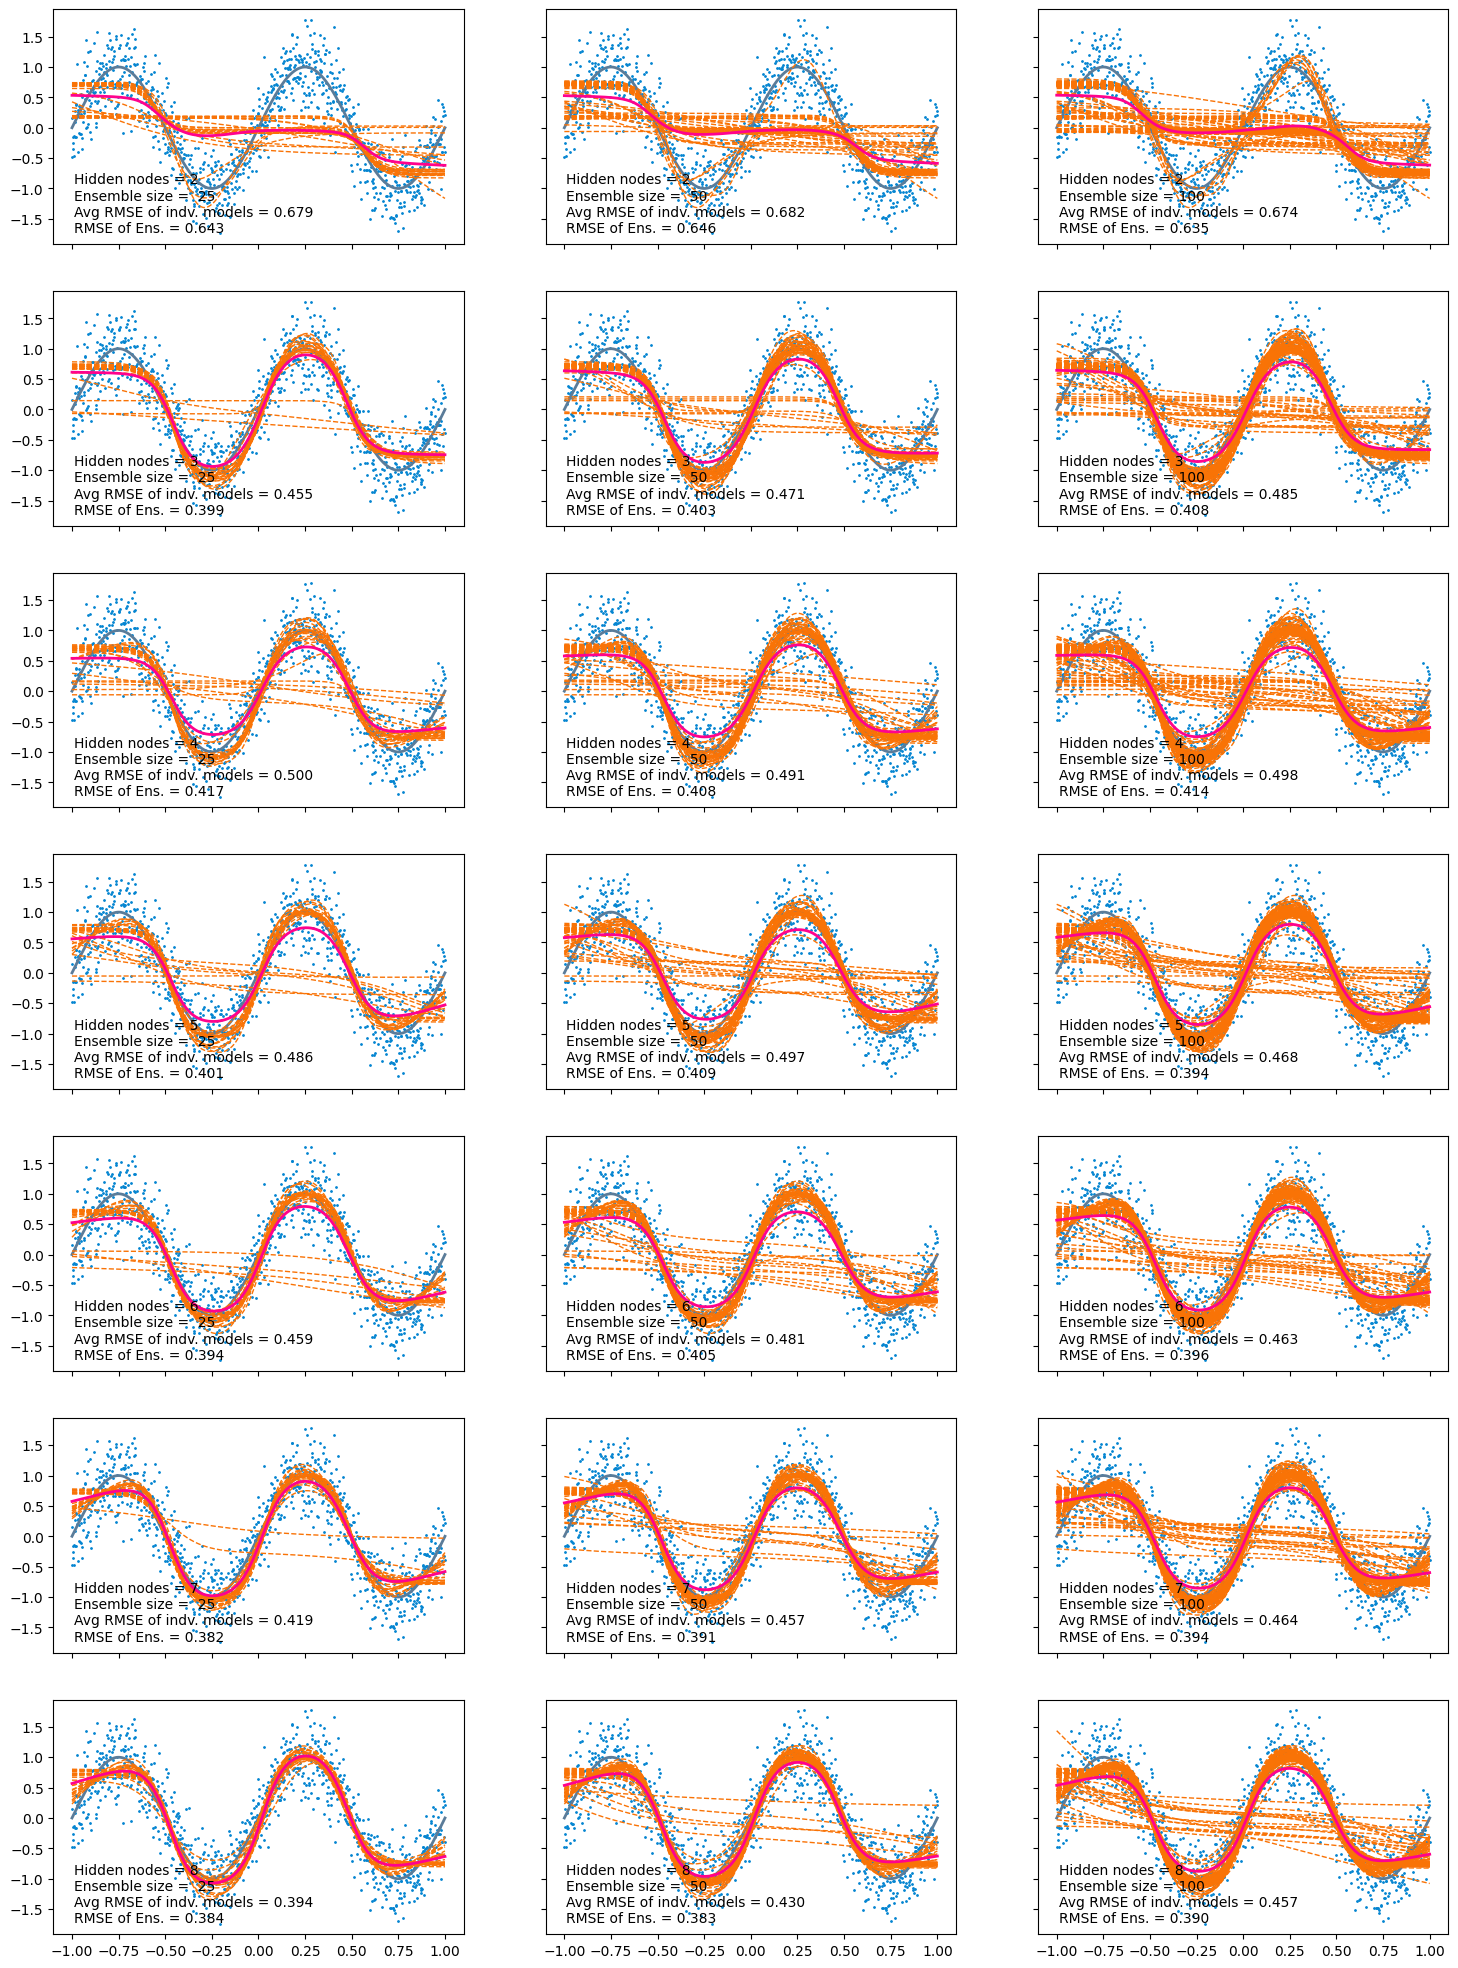

In [8]:
data_train = np.loadtxt('data_noise-0.5sigma_train.csv', delimiter=',')
X_train = data_train[:, 0].reshape(-1, 1)    # Need to reshape so the length in x is 1
y_train = data_train[:, 1]
data_test = np.loadtxt('data_noise-0.5sigma_test.csv', delimiter=',')
X_test = data_test[:, 0].reshape(-1, 1)    # Need to reshape so the length in x is 1
y_test = data_test[:, 1]
exec8_1_main_workflow(X_train, y_train, X_test, y_test, mlpnn_fixed_settings)

#### sigma = 2

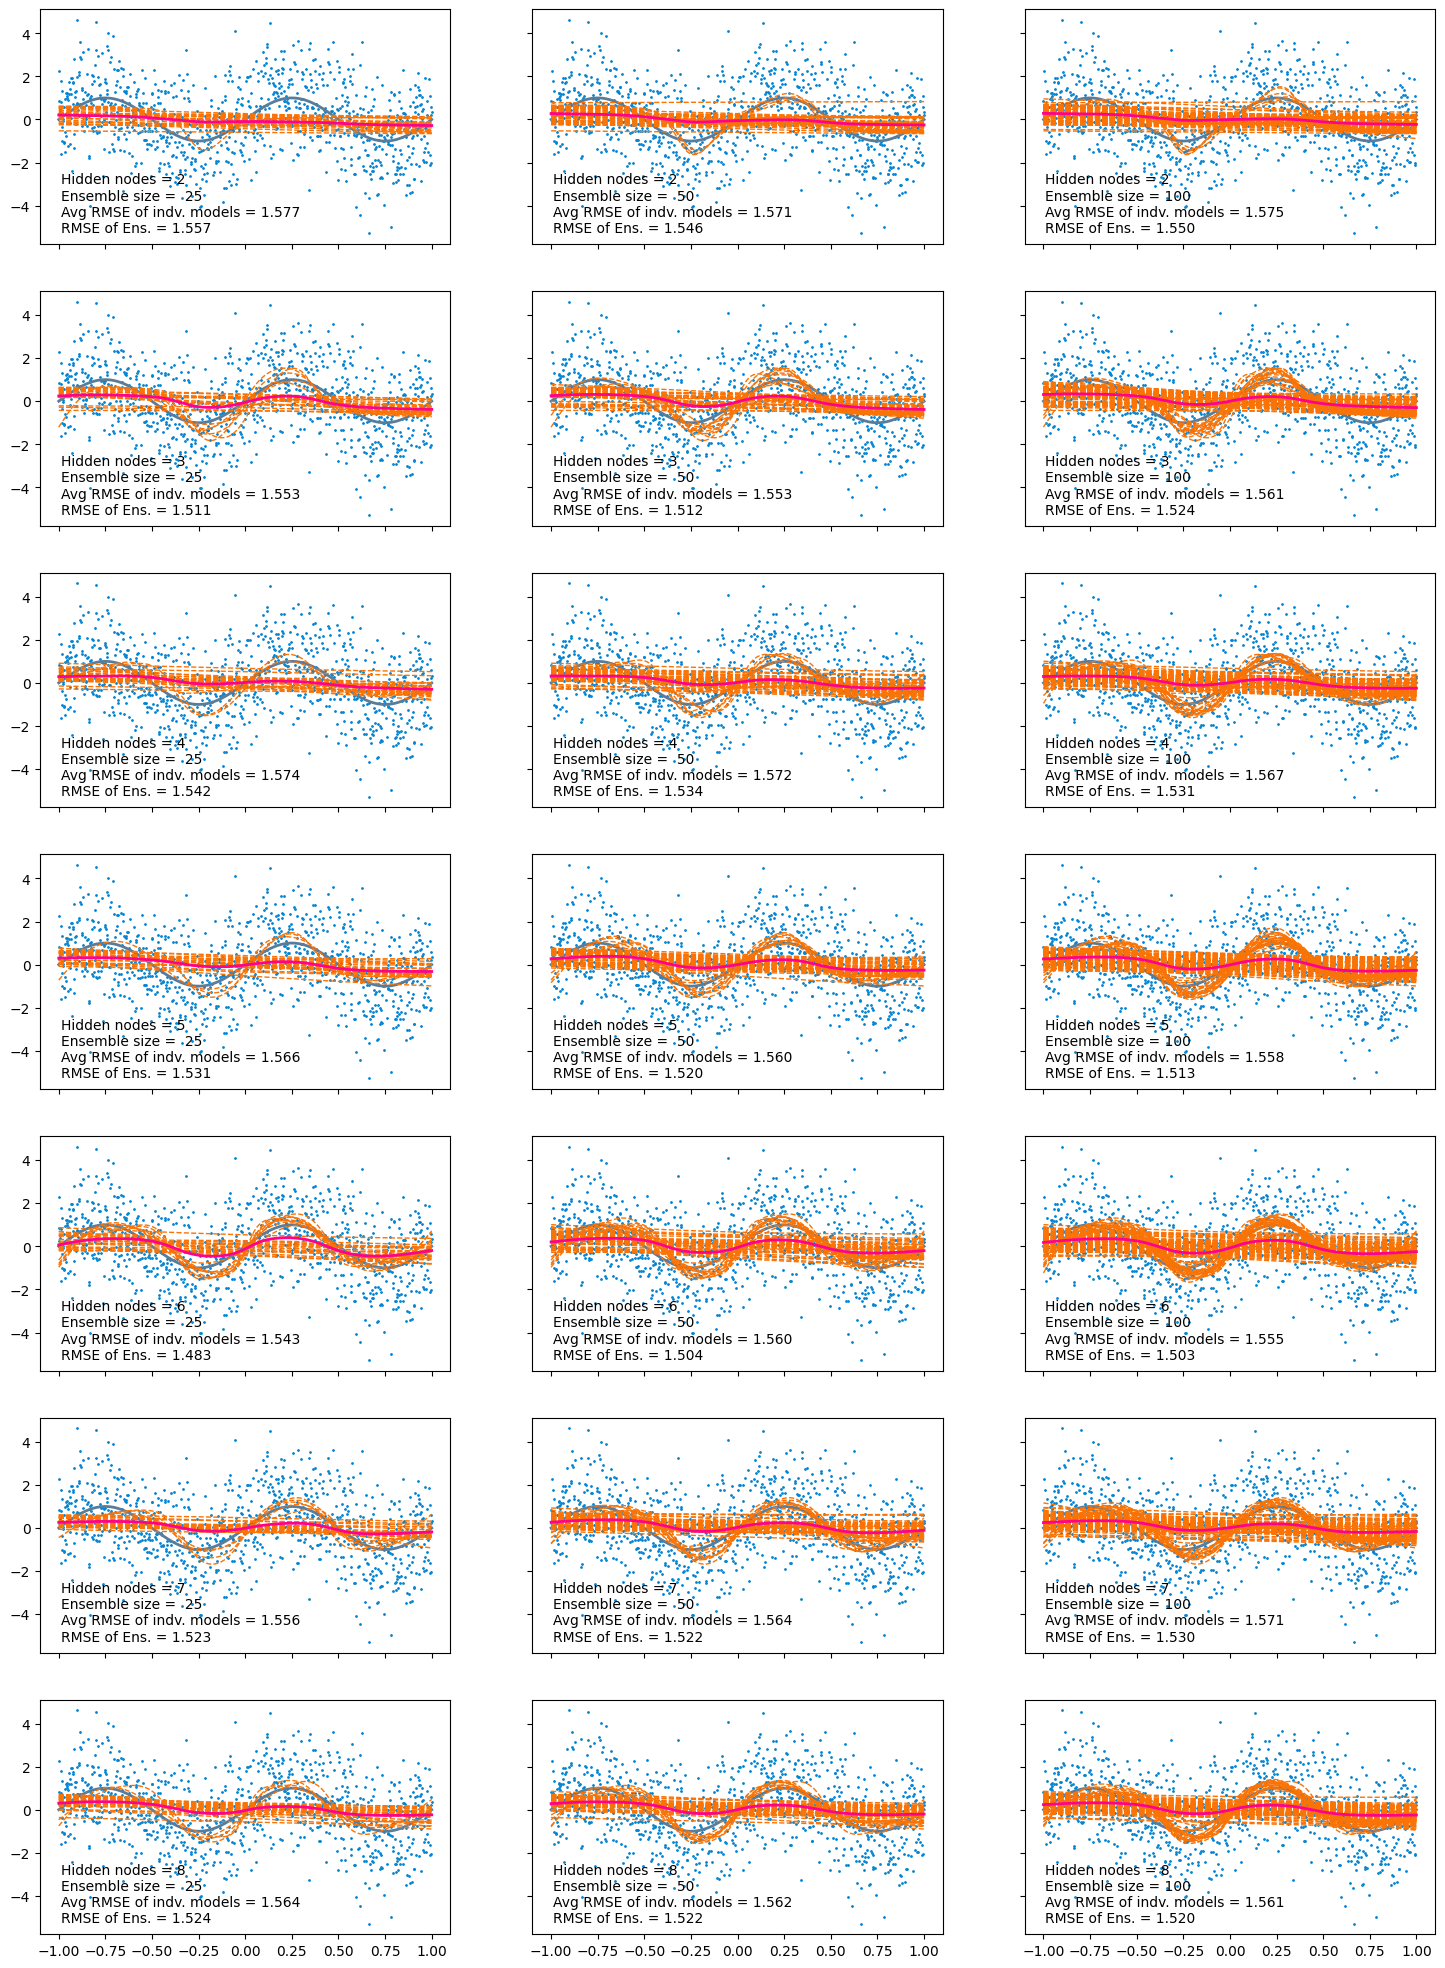

In [9]:
data_train = np.loadtxt('data_noise-2sigma_train.csv', delimiter=',')
X_train = data_train[:, 0].reshape(-1, 1)    # Need to reshape so the length in x is 1
y_train = data_train[:, 1]
data_test = np.loadtxt('data_noise-2sigma_test.csv', delimiter=',')
X_test = data_test[:, 0].reshape(-1, 1)    # Need to reshape so the length in x is 1
y_test = data_test[:, 1]
exec8_1_main_workflow(X_train, y_train, X_test, y_test, mlpnn_fixed_settings)

And our conclusions should still hold.

References:

[1] https://scikit-learn.org/stable/modules/neural_networks_supervised.html   (detailed, step-by-step ELM from scratch)

[2] https://towardsdatascience.com/build-an-extreme-learning-machine-in-python-91d1e8958599   (Visualization of our ELM model)